In [2]:
print("hello peter")

hello peter


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [12]:
from sklearn.metrics import(
     accuracy_score,
     precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc)

In [21]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Dataset shapes:",X.shape)
print("Classes:", np.unique(y))


Dataset shapes: (569, 30)
Classes: [0 1]


In [28]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42,
    stratify=y
)
 

In [30]:
scaler =StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
mle_model = LogisticRegression(
    penalty= None,
    max_iter=5000,
    random_state=42
)
mle_model.fit(X_train,y_train)
y_pred_mle = mle_model.predict(X_test)


In [80]:
map_l2= LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42,
)
map_l2.fit(X_train,y_train)
y_pred_l2=map_l2.predict(X_test)


In [81]:
map_l1=LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=5000,
    random_state=42,
)
map_l1.fit(X_train,y_train)
y_pred_l1=map_l2.predict(X_test)


In [82]:
def evaluate(model_name,y_true,y_pred):
    print("n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy:",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall  :",recall_score(y_true,y_pred))
    print("F1 Score:",f1_score(y_true,y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))

In [83]:
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP (L2)",y_test,y_pred_l1)
evaluate("MAP (L1)",y_test,y_pred_l2)

n ========================================
MLE
Accuracy: 0.9210526315789473
Precision: 0.9701492537313433
Recall  : 0.9027777777777778
F1 Score: 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]
n ========================================
MAP (L2)
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall  : 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]
n ========================================
MAP (L1)
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall  : 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]


In [85]:
print("Number of zero coefficients")
print("MLE:", np.sum(mle_model.coef_[0]==0))
print("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print("MAP L1:",np.sum(map_l1.coef_[0] == 0))

Number of zero coefficients
MLE: 0
MAP L2 : 0
MAP L1: 14


In [93]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 score"
])

models = [
      ("MLE",mle_model, y_pred_mle),
      ("MAR L2",map_l2 ,y_pred_l2),
      ("MAP L1", map_l1 , y_pred_l1)
  ]
for name,model,pred in models:
    results.loc[len(results)] = [
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test, pred),
        f1_score(y_test,pred)
        
    ]
print(results)

    Model  Accuracy  Precision    Recall  F1 score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAR L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.982456   0.986111  0.986111  0.986111


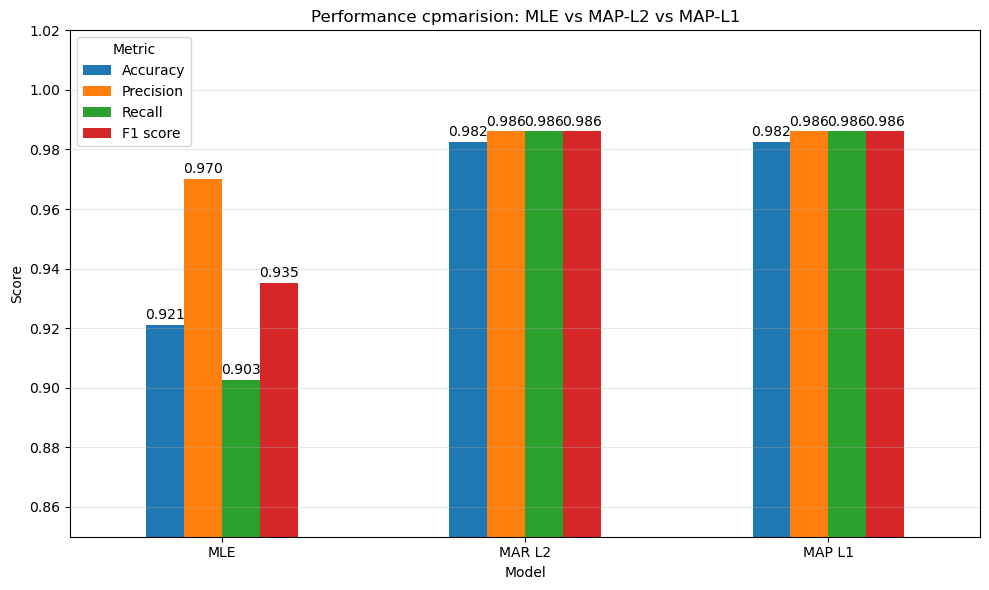

In [102]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Performance cpmarision: MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
#show values on bars
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f", padding=2)
plt.tight_layout()
plt.show()

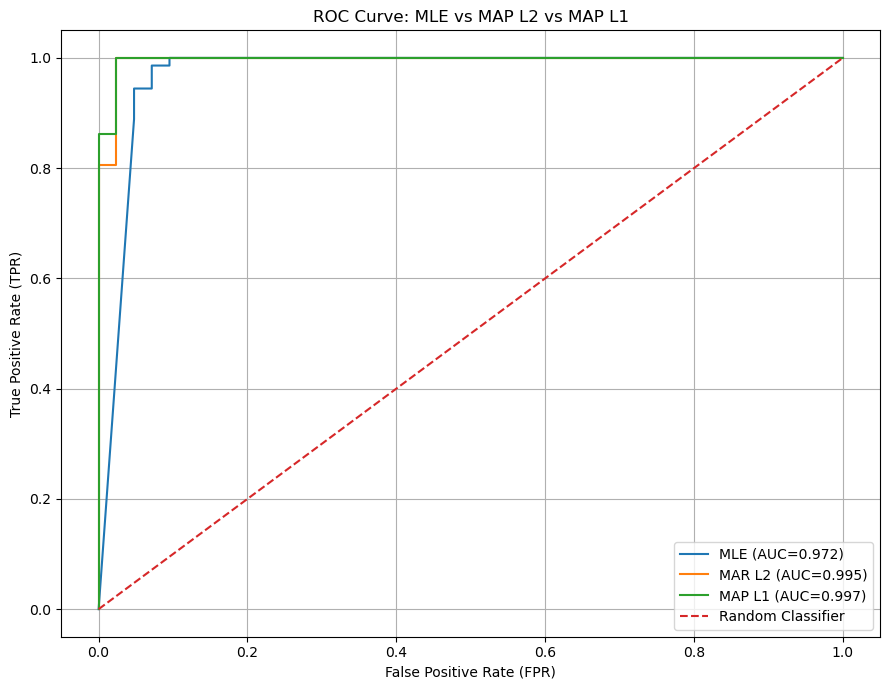

In [119]:
plt.figure(figsize=(9, 7))

for name, model, pred in models:
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()